In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [3]:
DATA_PATH = "../../data/processed_data/fsbi_sa_macros_pce_lag1_subset.csv"
IGNORE_COLS = ["Geo", "Sector Name", "Sub-Sector Name"]

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

df["Period"] = pd.to_datetime(df["Period"], errors="coerce")
df = df.dropna(subset=["Period"]).sort_values("Period").reset_index(drop=True)

# Drop IDs we are ignoring for modeling
work_df = df.drop(columns=[c for c in IGNORE_COLS if c in df.columns]).copy()

# Force numeric
for c in work_df.columns:
    if c != "Period":
        work_df[c] = pd.to_numeric(work_df[c], errors="coerce")

work_df.head()
work_df.columns

Index(['Period', 'Real Sales Index - SA_normalized',
       'Transactional Index - SA_normalized',
       'Real Sales MOM % - SA_normalized', 'Real Sales YOY % - SA_normalized',
       'Transaction MOM % - SA_normalized',
       'Transaction YOY %  - SA_normalized',
       'ConsumerSentimentIndex_normalized', 'CreditSpreadBAA_normalized',
       'CreditSpreadGS10_normalized', 'CrudeOilPrices_normalized',
       'ImportPriceIndex_normalized', 'Income_normalized',
       'JoltsQuitsRate_normalized', 'MonetaryCPI_normalized',
       'Unemployment_normalized', 'USNaturalGasCompositePrice_normalized',
       'Oil_ImportPrice_interaction', 'Unemployment_Income_interaction',
       'PersonalConsumptionExpenditures_normalized',
       'PersonalConsumptionExpenditures_normalized_lag1'],
      dtype='object')

In [14]:
import numpy as np
import pandas as pd

# --- 1) Ensure Period is a proper datetime and data is sorted ---
df = df.copy()
df.columns = df.columns.str.strip()

df["Period"] = pd.to_datetime(df["Period"], errors="coerce")
df = df.dropna(subset=["Period"]).sort_values("Period").reset_index(drop=True)

# --- 2) Choose the PCE PRICE INDEX LEVEL column ---
# IMPORTANT: this must be a PRICE INDEX level (e.g., PCEPI), not real PCE.
PCE_PRICE_LEVEL_COL = "PersonalConsumptionExpenditures_normalized"  # <-- change if needed

# Force numeric
df[PCE_PRICE_LEVEL_COL] = pd.to_numeric(df[PCE_PRICE_LEVEL_COL], errors="coerce")

# --- 3) Compute YoY inflation: π_t = 100 * (P_t / P_{t-12} - 1) ---
df["pce_yoy"] = 100.0 * (df[PCE_PRICE_LEVEL_COL] / df[PCE_PRICE_LEVEL_COL].shift(12) - 1.0)

# --- 4) Compute monthly change in YoY inflation (paper's dependent var) ---
# Δπ_t = π_t - π_{t-1}
df["dpce_yoy"] = df["pce_yoy"] - df["pce_yoy"].shift(1)

# --- 5) Add lags of Δπ (benchmark uses 2 lags) ---
df["dpce_yoy_lag1"] = df["dpce_yoy"].shift(1)
df["dpce_yoy_lag2"] = df["dpce_yoy"].shift(2)

# Optional: sanity check
print(df[["Period", PCE_PRICE_LEVEL_COL, "pce_yoy", "dpce_yoy"]].tail(20))

                          Period  PersonalConsumptionExpenditures_normalized  \
65 1970-01-01 00:00:00.020240601                                    0.978847   
66 1970-01-01 00:00:00.020240701                                    1.001288   
67 1970-01-01 00:00:00.020240801                                    1.018717   
68 1970-01-01 00:00:00.020240901                                    1.050044   
69 1970-01-01 00:00:00.020241001                                    1.087636   
70 1970-01-01 00:00:00.020241101                                    1.103925   
71 1970-01-01 00:00:00.020241201                                    1.142884   
72 1970-01-01 00:00:00.020250101                                    1.192779   
73 1970-01-01 00:00:00.020250201                                    1.250192   
74 1970-01-01 00:00:00.020250301                                    1.252470   
75 1970-01-01 00:00:00.020250401                                    1.276278   
76 1970-01-01 00:00:00.020250501        


=== IN-SAMPLE: Benchmark (HAC) ===
               Coefficient  StdErr(HAC)  t(HAC)
const               0.0156       0.0052  2.9825
dpce_yoy_lag1       0.4522       0.1409  3.2103
dpce_yoy_lag2       0.1023       0.0926  1.1043
In-sample MSE (Benchmark): 0.000571

=== IN-SAMPLE: FSBI-Augmented (HAC) ===
                                            Coefficient  StdErr(HAC)  t(HAC)
const                                            0.0123       0.0059  2.0853
d_Real Sales Index - SA_normalized               0.4301       0.3226  1.3332
d_Real Sales Index - SA_normalized_lag1          0.2988       0.2890  1.0336
d_Real Sales Index - SA_normalized_lag2          0.3023       0.2517  1.2008
d_Transactional Index - SA_normalized            0.2086       0.5403  0.3861
d_Transactional Index - SA_normalized_lag1       0.1108       0.5556  0.1995
d_Transactional Index - SA_normalized_lag2      -0.2457       0.5117 -0.4803
dpce_yoy_lag1                                    0.4337       0.1253  3.4627
dp

/var/folders/q2/3fx178d13zjcqv_8h929ssxh0000gn/T/ipykernel_6671/2257281065.py:191: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  preds[t] = float(res.predict(Xc_test))


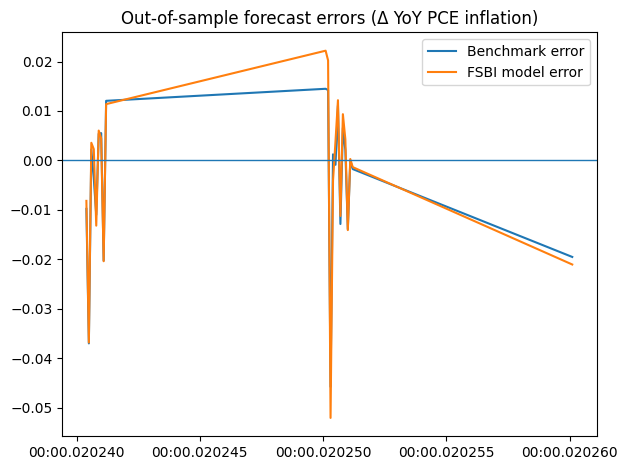

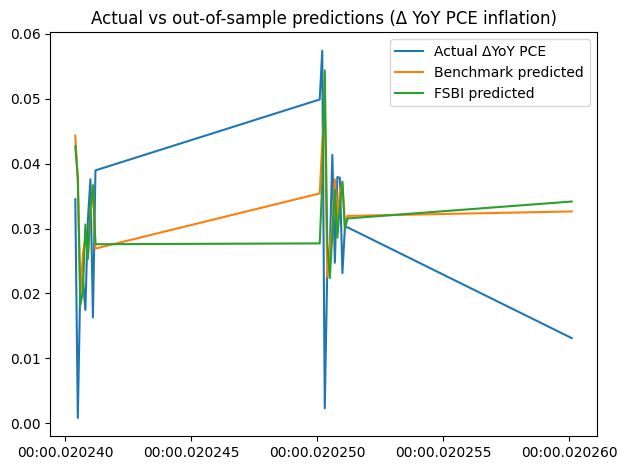

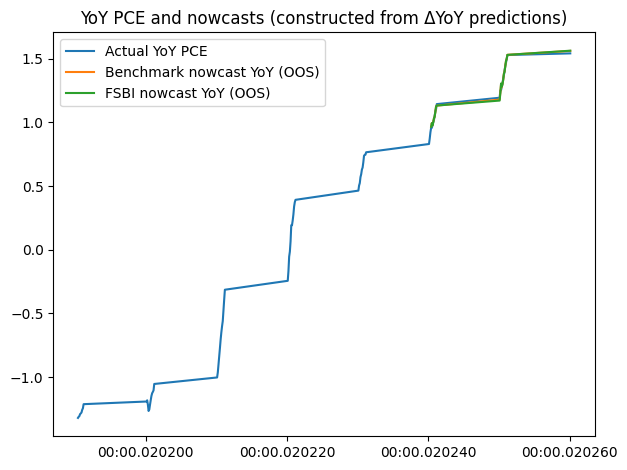

In [15]:
# ------------------------------------------------------------
# Replicate “Richmond-style” nowcast with FSBI activity data
# - Target: change in YoY inflation (Δπ_t = π_t - π_{t-1})
# - Benchmark: Δπ_t ~ Δπ_{t-1}, Δπ_{t-2}
# - FSBI model: add contemporaneous + 2 lags of FSBI signals
# - Out-of-sample (expanding window) evaluation + MSE reduction
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =========================
# 0) INPUTS YOU SET
# =========================

# You already have a df in memory; if not, load it:
# DATA_PATH = "../data/processed_data/fsbi_sa_macros_pce_lag1_subset.csv"
# df = pd.read_csv(DATA_PATH)

IGNORE_COLS = ["Geo", "Sector Name", "Sub-Sector Name"]

# ---- Choose your inflation target column(s) ----
# Option A: if you already have YoY inflation series in a column (recommended):
PCE_YOY_COL = "PersonalConsumptionExpenditures_normalized"

# Option B: if you only have an index level and need to compute YoY:
# PCE_LEVEL_COL = "PCE_Index_Level_Column_Name"  # uncomment and set if needed
PCE_LEVEL_COL = None  # set to column name if you want YoY computed from levels

# FSBI signals (your “early” indicators)
FSBI_LEVEL_COLS = [
    "Real Sales Index - SA_normalized",
    "Transactional Index - SA_normalized",
]

# If you prefer using the already-computed MoM% columns instead of level-diffs,
# set USE_MOM_PCT = True and list those columns here:
USE_MOM_PCT = False
FSBI_MOM_PCT_COLS = [
    "Real Sales MOM % - SA_normalized",
    "Transaction MOM % - SA_normalized",
]

# Lags (paper used up to 2 lags)
MAX_LAG = 2

# Out-of-sample settings
MIN_TRAIN_N = 60  # ~5 years monthly; adjust if your sample is shorter
HAC_LAGS = 3      # Newey-West HAC maxlags for SEs in in-sample table

# =========================
# 1) CLEAN + SORT
# =========================

df = df.copy()
df.columns = df.columns.str.strip()

df["Period"] = pd.to_datetime(df["Period"], errors="coerce")
df = df.dropna(subset=["Period"]).sort_values("Period").reset_index(drop=True)

# drop IDs you don't model with
work_df = df.drop(columns=[c for c in IGNORE_COLS if c in df.columns], errors="ignore").copy()

# force numeric for non-date cols
for c in work_df.columns:
    if c != "Period":
        work_df[c] = pd.to_numeric(work_df[c], errors="coerce")

# =========================
# 2) BUILD TARGET: Δπ_t (change in YoY PCE inflation)
# =========================

if PCE_LEVEL_COL is not None:
    # Compute YoY inflation from a level index (assumes monthly frequency)
    # π_t = 100 * (PCE_t / PCE_{t-12} - 1)
    work_df["pce_yoy"] = 100.0 * (work_df[PCE_LEVEL_COL] / work_df[PCE_LEVEL_COL].shift(12) - 1.0)
else:
    # Use provided YoY series directly. If it's not in percent units,
    # you can multiply by 100 here if needed.
    work_df["pce_yoy"] = work_df[PCE_YOY_COL]

# Δπ_t = π_t - π_{t-1}
work_df["dpce_yoy"] = work_df["pce_yoy"] - work_df["pce_yoy"].shift(1)

# Lags of Δπ
for k in range(1, MAX_LAG + 1):
    work_df[f"dpce_yoy_lag{k}"] = work_df["dpce_yoy"].shift(k)

# =========================
# 3) BUILD FSBI REGRESSORS (ΔS_t and its lags)
# =========================

if USE_MOM_PCT:
    fsbi_base = FSBI_MOM_PCT_COLS
    # These are already "change-like" series, so name them as d_*
    for c in fsbi_base:
        work_df[f"d_{c}"] = work_df[c]
else:
    fsbi_base = FSBI_LEVEL_COLS
    # Use month-to-month change in the index level: ΔS_t = S_t - S_{t-1}
    for c in fsbi_base:
        work_df[f"d_{c}"] = work_df[c] - work_df[c].shift(1)

# Add lags of ΔFSBI
fsbi_dcols = [f"d_{c}" for c in fsbi_base]
for dcol in fsbi_dcols:
    for k in range(1, MAX_LAG + 1):
        work_df[f"{dcol}_lag{k}"] = work_df[dcol].shift(k)

# =========================
# 4) ASSEMBLE MODEL MATRICES
# =========================

# Benchmark X: lags of Δπ only
X_bench_cols = [f"dpce_yoy_lag{k}" for k in range(1, MAX_LAG + 1)]

# FSBI model X: contemporaneous + lags of ΔFSBI plus lags of Δπ
X_fsbi_cols = []
for dcol in fsbi_dcols:
    X_fsbi_cols.append(dcol)  # contemporaneous
    for k in range(1, MAX_LAG + 1):
        X_fsbi_cols.append(f"{dcol}_lag{k}")
X_fsbi_cols += X_bench_cols

# Keep rows with complete data
model_df = work_df[["Period", "dpce_yoy"] + X_fsbi_cols].dropna().reset_index(drop=True)

y = model_df["dpce_yoy"].values
X_bench = model_df[X_bench_cols].values
X_fsbi = model_df[X_fsbi_cols].values
dates = model_df["Period"]

# =========================
# 5) IN-SAMPLE ESTIMATION + HAC (Newey-West) TABLES
# =========================

def fit_ols_hac(y_vec, X_mat, colnames, hac_lags=3):
    Xc = sm.add_constant(X_mat, has_constant="add")
    res = sm.OLS(y_vec, Xc).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
    params = res.params
    se = res.bse
    tvals = res.tvalues
    out = pd.DataFrame(
        {"Coefficient": params, "StdErr(HAC)": se, "t(HAC)": tvals},
        index=["const"] + colnames
    )
    return res, out

res_bench, tab_bench = fit_ols_hac(y, X_bench, X_bench_cols, hac_lags=HAC_LAGS)
res_fsbi, tab_fsbi = fit_ols_hac(y, X_fsbi, X_fsbi_cols, hac_lags=HAC_LAGS)

insample_mse_bench = mean_squared_error(y, res_bench.fittedvalues)
insample_mse_fsbi = mean_squared_error(y, res_fsbi.fittedvalues)

print("\n=== IN-SAMPLE: Benchmark (HAC) ===")
print(tab_bench.round(4))
print(f"In-sample MSE (Benchmark): {insample_mse_bench:.6f}")

print("\n=== IN-SAMPLE: FSBI-Augmented (HAC) ===")
print(tab_fsbi.round(4))
print(f"In-sample MSE (FSBI): {insample_mse_fsbi:.6f}")
print(f"MSE reduction: {(1 - insample_mse_fsbi/insample_mse_bench)*100:.2f}%")

# =========================
# 6) OUT-OF-SAMPLE NOWCAST (EXPANDING WINDOW)
# =========================

def expanding_oos_forecast(y_vec, X_mat, min_train_n=60):
    """
    One-step-ahead predictions:
      - for t from min_train_n to T-1:
          fit on [0..t-1], predict y[t]
    """
    T = len(y_vec)
    preds = np.full(T, np.nan)

    for t in range(min_train_n, T):
        y_train = y_vec[:t]
        X_train = X_mat[:t, :]
        X_test = X_mat[t:t+1, :]

        # OLS with intercept
        Xc_train = sm.add_constant(X_train, has_constant="add")
        Xc_test = sm.add_constant(X_test, has_constant="add")

        res = sm.OLS(y_train, Xc_train).fit()
        preds[t] = float(res.predict(Xc_test))

    return preds

pred_bench = expanding_oos_forecast(y, X_bench, min_train_n=MIN_TRAIN_N)
pred_fsbi = expanding_oos_forecast(y, X_fsbi, min_train_n=MIN_TRAIN_N)

oos_mask = ~np.isnan(pred_bench) & ~np.isnan(pred_fsbi)

y_oos = y[oos_mask]
pb_oos = pred_bench[oos_mask]
pf_oos = pred_fsbi[oos_mask]
dates_oos = dates[oos_mask]

mse_b = mean_squared_error(y_oos, pb_oos)
mse_f = mean_squared_error(y_oos, pf_oos)
mae_b = mean_absolute_error(y_oos, pb_oos)
mae_f = mean_absolute_error(y_oos, pf_oos)

print("\n=== OUT-OF-SAMPLE (Expanding Window) ===")
print(f"OOS MSE Benchmark: {mse_b:.6f}")
print(f"OOS MSE FSBI     : {mse_f:.6f}")
print(f"OOS MSE reduction: {(1 - mse_f/mse_b)*100:.2f}%")
print(f"OOS MAE Benchmark: {mae_b:.6f}")
print(f"OOS MAE FSBI     : {mae_f:.6f}")

# =========================
# 7) PLOTS (like Figures 5-6 style, but for ΔYoY)
# =========================

# Plot OOS forecast errors
err_b = y_oos - pb_oos
err_f = y_oos - pf_oos

plt.figure()
plt.plot(dates_oos, err_b, label="Benchmark error")
plt.plot(dates_oos, err_f, label="FSBI model error")
plt.axhline(0, linewidth=1)
plt.title("Out-of-sample forecast errors (Δ YoY PCE inflation)")
plt.legend()
plt.tight_layout()
plt.show()

# Plot actual vs predicted ΔYoY
plt.figure()
plt.plot(dates_oos, y_oos, label="Actual ΔYoY PCE")
plt.plot(dates_oos, pb_oos, label="Benchmark predicted")
plt.plot(dates_oos, pf_oos, label="FSBI predicted")
plt.title("Actual vs out-of-sample predictions (Δ YoY PCE inflation)")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 8) OPTIONAL: Convert ΔYoY predictions into YoY level nowcast
# =========================
# If you want a nowcast of YoY PCE itself:
#   π̂_t = π_{t-1} + Δπ̂_t
# (Only meaningful if you have pce_yoy aligned with model_df)
pce_yoy_aligned = work_df.set_index("Period").loc[dates, "pce_yoy"].values
pce_yoy_hat_b = np.full_like(pce_yoy_aligned, np.nan, dtype=float)
pce_yoy_hat_f = np.full_like(pce_yoy_aligned, np.nan, dtype=float)

# Align: for OOS portion, use last month's actual YoY + predicted ΔYoY
for i, dt in enumerate(dates):
    if i == 0:
        continue
    if oos_mask[i]:
        pce_yoy_hat_b[i] = pce_yoy_aligned[i-1] + pred_bench[i]
        pce_yoy_hat_f[i] = pce_yoy_aligned[i-1] + pred_fsbi[i]

plt.figure()
plt.plot(dates, pce_yoy_aligned, label="Actual YoY PCE")
plt.plot(dates, pce_yoy_hat_b, label="Benchmark nowcast YoY (OOS)")
plt.plot(dates, pce_yoy_hat_f, label="FSBI nowcast YoY (OOS)")
plt.title("YoY PCE and nowcasts (constructed from ΔYoY predictions)")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- Columns ---
sales_col = "Real Sales Index - SA_normalized"
txn_col   = "Transactional Index - SA_normalized"
pce_col   = "PersonalConsumptionExpenditures_normalized"  # PCE price index level

MAX_PI_LAG = 2
MIN_TRAIN_N = 48  # for 84 obs, start with 4 years train; you can try 36, 48, 60

df = df.copy()
df.columns = df.columns.str.strip()
df["Period"] = pd.to_datetime(df["Period"], errors="coerce")
df = df.dropna(subset=["Period"]).sort_values("Period").reset_index(drop=True)

# --- Build YoY PCE inflation and ΔYoY (target) ---
df[pce_col] = pd.to_numeric(df[pce_col], errors="coerce")
df["pce_yoy"] = 100.0 * (df[pce_col] / df[pce_col].shift(12) - 1.0)
df["dpce_yoy"] = df["pce_yoy"] - df["pce_yoy"].shift(1)

# --- Inflation lags ---
for k in range(1, MAX_PI_LAG + 1):
    df[f"dpce_yoy_lag{k}"] = df["dpce_yoy"].shift(k)

# --- FSBI changes ---
df[sales_col] = pd.to_numeric(df[sales_col], errors="coerce")
df[txn_col]   = pd.to_numeric(df[txn_col], errors="coerce")

df["d_sales"] = df[sales_col] - df[sales_col].shift(1)
df["d_txn"]   = df[txn_col] - df[txn_col].shift(1)

# --- Standardize FSBI changes (z-scores) using full-sample mean/std ---
# (For strict real-time purity you can standardize within each training window,
#  but start simple first.)
df["z_d_sales"] = (df["d_sales"] - df["d_sales"].mean()) / df["d_sales"].std(ddof=0)
df["z_d_txn"]   = (df["d_txn"]   - df["d_txn"].mean())   / df["d_txn"].std(ddof=0)

# Composite early indicator
df["fsbi_comp"] = 0.5 * df["z_d_sales"] + 0.5 * df["z_d_txn"]
df["fsbi_comp_lag1"] = df["fsbi_comp"].shift(1)

# --- Model datasets ---
use_cols = ["Period", "dpce_yoy", "dpce_yoy_lag1", "dpce_yoy_lag2", "fsbi_comp", "fsbi_comp_lag1"]
mdf = df[use_cols].dropna().reset_index(drop=True)

y = mdf["dpce_yoy"].values
dates = mdf["Period"]

# Benchmark X
X_bench = mdf[["dpce_yoy_lag1", "dpce_yoy_lag2"]].values

# FSBI X (parsimonious)
X_fsbi  = mdf[["fsbi_comp", "fsbi_comp_lag1", "dpce_yoy_lag1", "dpce_yoy_lag2"]].values

def expanding_oos(y_vec, X_mat, min_train_n):
    T = len(y_vec)
    preds = np.full(T, np.nan)
    for t in range(min_train_n, T):
        y_tr = y_vec[:t]
        X_tr = sm.add_constant(X_mat[:t, :], has_constant="add")
        X_te = sm.add_constant(X_mat[t:t+1, :], has_constant="add")
        res = sm.OLS(y_tr, X_tr).fit()
        preds[t] = float(res.predict(X_te))
    return preds

pred_b = expanding_oos(y, X_bench, MIN_TRAIN_N)
pred_f = expanding_oos(y, X_fsbi,  MIN_TRAIN_N)

mask = ~np.isnan(pred_b) & ~np.isnan(pred_f)
y_oos = y[mask]
pb = pred_b[mask]
pf = pred_f[mask]

mse_b = mean_squared_error(y_oos, pb)
mse_f = mean_squared_error(y_oos, pf)
mae_b = mean_absolute_error(y_oos, pb)
mae_f = mean_absolute_error(y_oos, pf)

print("\n=== OOS (Expanding Window) ===")
print(f"OOS MSE Benchmark: {mse_b:.6f}")
print(f"OOS MSE FSBI     : {mse_f:.6f}")
print(f"OOS MSE reduction: {(1 - mse_f/mse_b)*100:.2f}%")
print(f"OOS MAE Benchmark: {mae_b:.6f}")
print(f"OOS MAE FSBI     : {mae_f:.6f}")


=== OOS (Expanding Window) ===
OOS MSE Benchmark: 58.169870
OOS MSE FSBI     : 401.094687
OOS MSE reduction: -589.52%
OOS MAE Benchmark: 5.989139
OOS MAE FSBI     : 14.797904


/var/folders/q2/3fx178d13zjcqv_8h929ssxh0000gn/T/ipykernel_6671/568464321.py:66: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  preds[t] = float(res.predict(X_te))


In [4]:
PCE = "PersonalConsumptionExpenditures_normalized"
PCE_LAG1 = "PersonalConsumptionExpenditures_normalized_lag1"

if PCE not in work_df.columns or PCE_LAG1 not in work_df.columns:
    raise ValueError("Need both PCE and PCE_lag1 in the dataset.")

work_df["PCE_diff"] = work_df[PCE] - work_df[PCE_LAG1]

In [5]:
# Seasonally adjusted FSBI columns only
fsbi_sa_cols = [
    "Real Sales Index - SA_normalized",
    "Transactional Index - SA_normalized",
    "Real Sales MOM % - SA_normalized",
    "Real Sales YOY % - SA_normalized",
    "Transaction MOM % - SA_normalized",
    "Transaction YOY %  - SA_normalized",
]
fsbi_sa_cols = [c for c in fsbi_sa_cols if c in work_df.columns]

# Base normalized macro levels only (no lags, no MA, no MoM/YoY)
macro_cols = [
    "ConsumerSentimentIndex_normalized",
    "CreditSpreadBAA_normalized",
    "CreditSpreadGS10_normalized",
    "CrudeOilPrices_normalized",
    "ImportPriceIndex_normalized",
    "Income_normalized",
    "JoltsQuitsRate_normalized",
    "MonetaryCPI_normalized",
    "Unemployment_normalized",
    "USNaturalGasCompositePrice_normalized",
]
macro_cols = [c for c in macro_cols if c in work_df.columns]


features = fsbi_sa_cols + macro_cols
print("Num features:", len(features))
print(features)

Num features: 16
['Real Sales Index - SA_normalized', 'Transactional Index - SA_normalized', 'Real Sales MOM % - SA_normalized', 'Real Sales YOY % - SA_normalized', 'Transaction MOM % - SA_normalized', 'Transaction YOY %  - SA_normalized', 'ConsumerSentimentIndex_normalized', 'CreditSpreadBAA_normalized', 'CreditSpreadGS10_normalized', 'CrudeOilPrices_normalized', 'ImportPriceIndex_normalized', 'Income_normalized', 'JoltsQuitsRate_normalized', 'MonetaryCPI_normalized', 'Unemployment_normalized', 'USNaturalGasCompositePrice_normalized']


In [6]:
model_df = work_df[["Period", "PCE_diff"] + features].dropna().copy()

print("Rows:", len(model_df))
print("Unique months:", model_df["Period"].nunique())
print("Date range:", model_df["Period"].min(), "->", model_df["Period"].max())


Rows: 84
Unique months: 84
Date range: 1970-01-01 00:00:00.020190201 -> 1970-01-01 00:00:00.020260101


In [7]:
unique_periods = sorted(model_df["Period"].unique())
if len(unique_periods) < 6:
    print("Warning: very few months available. Consider a smaller holdout or skip holdout.")

test_periods = set(unique_periods[-3:])

train = model_df[~model_df["Period"].isin(test_periods)].copy()
test  = model_df[ model_df["Period"].isin(test_periods)].copy()

X_train, y_train = train[features].values, train["PCE_diff"].values
X_test, y_test   = test[features].values, test["PCE_diff"].values

print("Train rows:", len(train), "Test rows:", len(test))
print("Test months:", sorted(test_periods))


Train rows: 81 Test rows: 3
Test months: [Timestamp('1970-01-01 00:00:00.020251101'), Timestamp('1970-01-01 00:00:00.020251201'), Timestamp('1970-01-01 00:00:00.020260101')]


In [8]:
baseline_pred = np.zeros_like(y_test)
print("Baseline (predict 0) Test RMSE:", np.sqrt(mean_squared_error(y_test, baseline_pred)))
print("Baseline (predict 0) Test MAE:", mean_absolute_error(y_test, baseline_pred))


Baseline (predict 0) Test RMSE: 0.025782184623050246
Baseline (predict 0) Test MAE: 0.024491594298470032


In [9]:
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge.fit(X_train, y_train)
test["pred_ridge"] = ridge.predict(X_test)

print("Ridge Test R2 (row-level):", r2_score(y_test, test["pred_ridge"]))
print("Ridge Test RMSE (row-level):", np.sqrt(mean_squared_error(y_test, test["pred_ridge"])))
print("Ridge Test MAE (row-level):", mean_absolute_error(y_test, test["pred_ridge"]))


Ridge Test R2 (row-level): -4.262542235844625
Ridge Test RMSE (row-level): 0.018478331972484136
Ridge Test MAE (row-level): 0.01758543274761896


In [10]:
test_month = test.groupby("Period")[["PCE_diff", "pred_ridge"]].mean().sort_index()

y_m = test_month["PCE_diff"].values
p_m = test_month["pred_ridge"].values

print("Ridge Test R2 (month-level):", r2_score(y_m, p_m))
print("Ridge Test RMSE (month-level):", np.sqrt(mean_squared_error(y_m, p_m)))
print("Ridge Test MAE (month-level):", mean_absolute_error(y_m, p_m))

test_month


Ridge Test R2 (month-level): -4.262542235844625
Ridge Test RMSE (month-level): 0.018478331972484136
Ridge Test MAE (month-level): 0.01758543274761896


,PCE_diff,pred_ridge
Period,,
1970-01-01 00:00:00.020251101,0.030187,0.012839
1970-01-01 00:00:00.020251201,0.030187,0.019430
1970-01-01 00:00:00.020260101,0.013100,0.037751


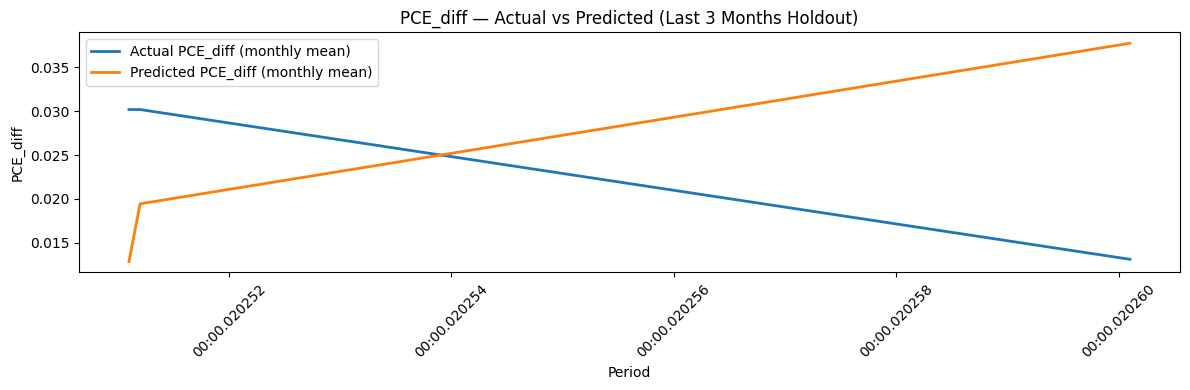

In [11]:
plt.figure(figsize=(12,4))
plt.plot(test_month.index, test_month["PCE_diff"], linewidth=2, label="Actual PCE_diff (monthly mean)")
plt.plot(test_month.index, test_month["pred_ridge"], linewidth=2, label="Predicted PCE_diff (monthly mean)")
plt.title("PCE_diff — Actual vs Predicted (Last 3 Months Holdout)")
plt.xlabel("Period")
plt.ylabel("PCE_diff")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [12]:
enet = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=20000, random_state=0))
])

param_grid = {
    "model__alpha": np.logspace(-4, 1.5, 25),
    "model__l1_ratio": [0.05, 0.2, 0.5, 0.8, 0.95]
}

# CV on TRAIN only
n_splits = min(5, max(3, train["Period"].nunique() // 6))
tscv = TimeSeriesSplit(n_splits=n_splits)

grid = GridSearchCV(enet, param_grid, cv=tscv, scoring="neg_mean_squared_error", n_jobs=-1)
grid.fit(X_train, y_train)

best_enet = grid.best_estimator_
print("Best params:", grid.best_params_)

test["pred_enet"] = best_enet.predict(X_test)

# Month-level evaluation for ElasticNet
test_month2 = test.groupby("Period")[["PCE_diff", "pred_enet"]].mean().sort_index()
y_m2 = test_month2["PCE_diff"].values
p_m2 = test_month2["pred_enet"].values

print("ElasticNet Test R2 (month-level):", r2_score(y_m2, p_m2))
print("ElasticNet Test RMSE (month-level):", np.sqrt(mean_squared_error(y_m2, p_m2)))
print("ElasticNet Test MAE (month-level):", mean_absolute_error(y_m2, p_m2))


Best params: {'model__alpha': np.float64(0.09531618832347873), 'model__l1_ratio': 0.05}
ElasticNet Test R2 (month-level): -5.800928885827479
ElasticNet Test RMSE (month-level): 0.021006276843468244
ElasticNet Test MAE (month-level): 0.013786820681529676


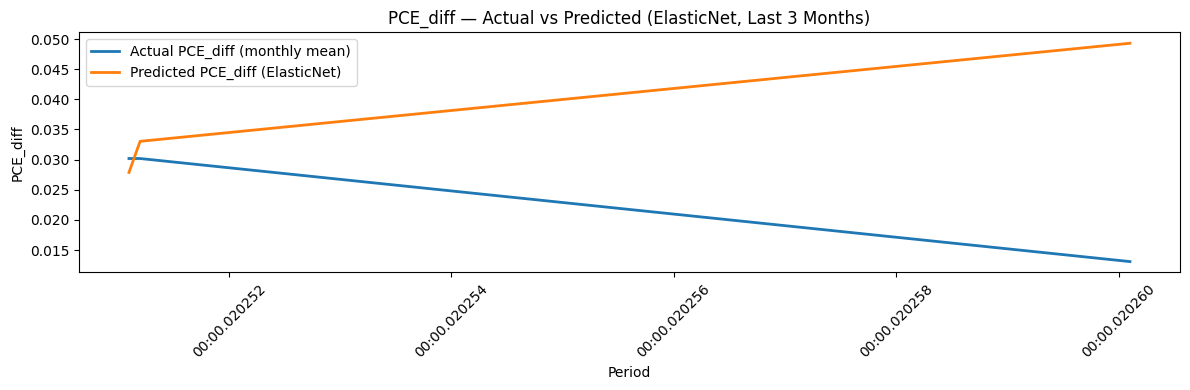

In [13]:
plt.figure(figsize=(12,4))
plt.plot(test_month2.index, test_month2["PCE_diff"], linewidth=2, label="Actual PCE_diff (monthly mean)")
plt.plot(test_month2.index, test_month2["pred_enet"], linewidth=2, label="Predicted PCE_diff (ElasticNet)")
plt.title("PCE_diff — Actual vs Predicted (ElasticNet, Last 3 Months)")
plt.xlabel("Period")
plt.ylabel("PCE_diff")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
